In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [2]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast

shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_store1.csv", index_col=0)
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates_store1.csv", index_col=0)

df = shop_sales.merge(shop_dates, on="date_id", how="left")
df = df[['item_id', 'date', 'cnt']]

In [7]:
# создаём MultiItemForecaster
multi_fc = MultiItemForecaster(model_name="ets")

# обучаем модели на каждом товаре
multi_fc.fit(df, seasonal_periods=7, trend=None, seasonal='add')

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=30)
metrics_agg

{'SMAPE': np.float64(89.43431232603604),
 'WAPE': np.float64(inf),
 'RMSE': np.float64(10.133248638731086),
 'MASE': np.float64(1.4434687330682516)}

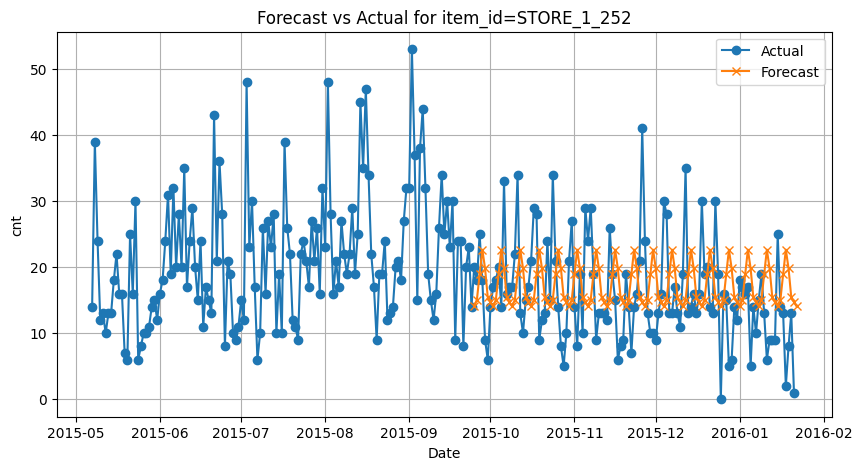

In [8]:
# прогноз на неделю
forecasts = multi_fc.predict(horizon=120)

plot_forecast(df, forecasts, item_id='STORE_1_252', horizon=120, last_k_days=260)


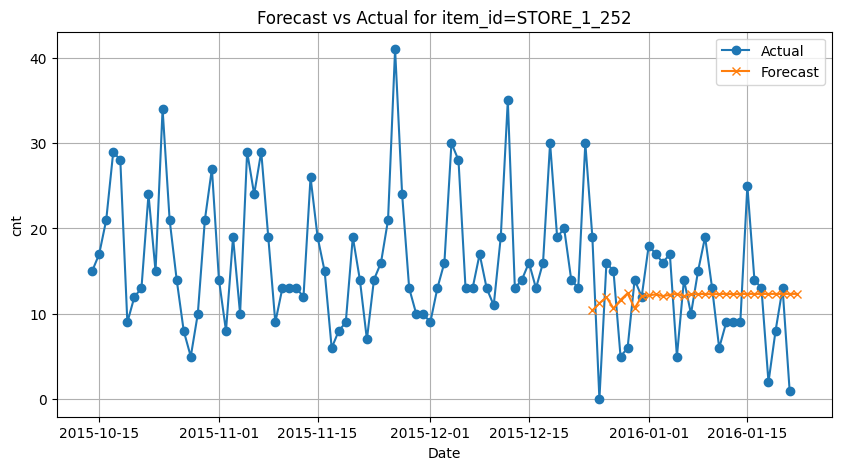

{'SMAPE': np.float64(88.81253875351301),
 'WAPE': np.float64(inf),
 'RMSE': np.float64(10.078865253788331),
 'MASE': np.float64(1.4261418824257035)}

In [15]:
horizon = 30
last_k_days = 100

multi_fc = MultiItemForecaster(model_name="arima")
multi_fc.fit(df, order=(1,1,1), seasonal_order=(1,0,0,7))

forecasts = multi_fc.predict(horizon=horizon)

plot_forecast(df, forecasts, item_id='STORE_1_252', horizon=horizon, last_k_days=last_k_days)

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon)
metrics_agg

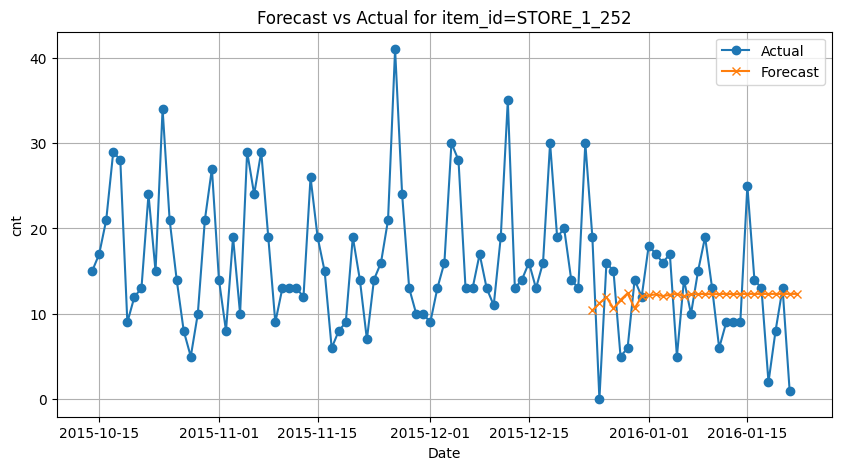

{'SMAPE': np.float64(88.81253875351301),
 'WAPE': np.float64(inf),
 'RMSE': np.float64(10.078865253788331),
 'MASE': np.float64(1.4261418824257035)}

In [ ]:
horizon = 30
last_k_days = 100

multi_fc = MultiItemForecaster(model_name="arima")
multi_fc.fit(df, order=(1,1,1), seasonal_order=(1,0,0,7))

forecasts = multi_fc.predict(horizon=horizon)

plot_forecast(df, forecasts, item_id='STORE_1_252', horizon=horizon, last_k_days=last_k_days)

metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon)
metrics_agg

In [48]:
df.item_id.unique()

array(['STORE_1_046', 'STORE_1_033', 'STORE_1_043', 'STORE_1_090',
       'STORE_1_099', 'STORE_1_131', 'STORE_1_252', 'STORE_1_295',
       'STORE_1_304', 'STORE_1_491', 'STORE_1_542', 'STORE_1_555',
       'STORE_1_586', 'STORE_1_587', 'STORE_1_714'], dtype=object)

In [50]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[df.item_id == 'STORE_1_542'].cnt)
print('ADF p-value:', result[1])

ADF p-value: 1.9431540287504534e-06
